In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [3]:
df = pd.read_csv("../data/processed/model_dataset.csv")

X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
scaler = joblib.load("../models/saved_models/scaler.pkl")

X_train_normal = X_train[y_train == 0]

X_train_normal = scaler.transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

In [5]:
from torch.utils.data import Dataset

class NetworkDataset(Dataset):

    def __init__(self, data):
        self.data = torch.FloatTensor(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [6]:
from torch.utils.data import DataLoader

train_dataset = NetworkDataset(X_train_normal)
test_dataset = NetworkDataset(X_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [8]:
INPUT_DIM = X_train_normal.shape[1]

model = Autoencoder(INPUT_DIM).to(device)

model.load_state_dict(
    torch.load("../models/saved_models/autoencoder.pth", map_location=device)
)

model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=59, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=59, bias=True)
  )
)

In [9]:
criterion = nn.MSELoss(reduction="none")

In [10]:
train_errors = []

with torch.no_grad():

    for batch in train_loader:

        batch = batch.to(device)

        output = model(batch)

        loss = criterion(output, batch)

        loss = loss.mean(dim=1)

        train_errors.extend(loss.cpu().numpy())

In [19]:
thresholds = {
    "90%": np.percentile(train_errors, 90),
    "95%": np.percentile(train_errors, 95),
    "97%": np.percentile(train_errors, 97),
    "99%": np.percentile(train_errors, 99)
}

for name, value in thresholds.items():
    print(f"{name} Threshold: {value:.6f}")

90% Threshold: 0.003292
95% Threshold: 0.007469
97% Threshold: 0.012667
99% Threshold: 0.029405


In [12]:
test_errors = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        output = model(batch)

        loss = criterion(output, batch)

        loss = loss.mean(dim=1)

        test_errors.extend(loss.cpu().numpy())

In [13]:
y_pred = np.array(test_errors) > threshold

y_pred = y_pred.astype(int)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8310814027292923
Precision: 0.1111111111111111
Recall   : 2.3488514116596984e-05
F1 Score : 4.696709954676749e-05


In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[418996     16]
 [ 85146      2]]


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91    419012
           1       0.11      0.00      0.00     85148

    accuracy                           0.83    504160
   macro avg       0.47      0.50      0.45    504160
weighted avg       0.71      0.83      0.75    504160



In [17]:
joblib.dump(
    threshold,
    "../models/saved_models/ae_threshold.pkl"
)

print("Threshold saved.")

Threshold saved.


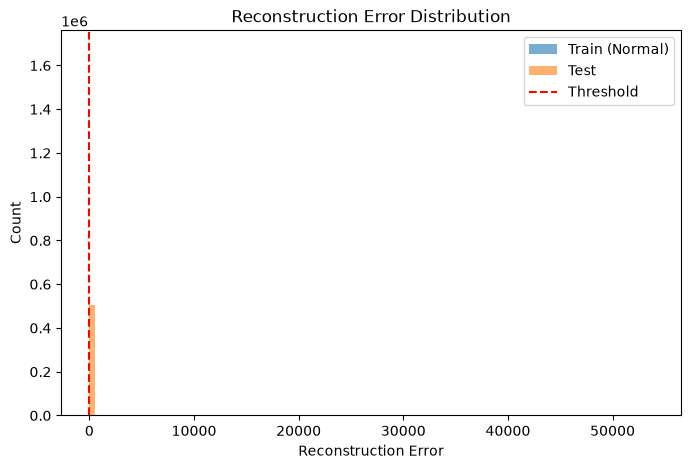

In [18]:
plt.figure(figsize=(8,5))

plt.hist(train_errors, bins=100, alpha=0.6, label="Train (Normal)")
plt.hist(test_errors, bins=100, alpha=0.6, label="Test")

plt.axvline(threshold,
            color="red",
            linestyle="--",
            label="Threshold")

plt.legend()

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")

plt.show()

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

results = []

for name, threshold in thresholds.items():

    y_pred = (np.array(test_errors) > threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append([
        name,
        threshold,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Value",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df

,Threshold,Value,Accuracy,Precision,Recall,F1
0,90%,0.003292,0.849839,0.550709,0.602199,0.575304
1,95%,0.007469,0.890559,0.708759,0.597536,0.648413
2,97%,0.012667,0.905841,0.800191,0.589750,0.679040
3,99%,0.029405,0.913071,0.915698,0.534505,0.675002


In [21]:
for name, threshold in thresholds.items():

    y_pred = (np.array(test_errors) > threshold).astype(int)

    print(f"\n{name} Threshold")
    print(confusion_matrix(y_test, y_pred))


90% Threshold
[[377179  41833]
 [ 33872  51276]]

95% Threshold
[[398105  20907]
 [ 34269  50879]]

97% Threshold
[[406473  12539]
 [ 34932  50216]]

99% Threshold
[[414822   4190]
 [ 39636  45512]]


In [22]:
import joblib

BEST_THRESHOLD = thresholds["97%"]

joblib.dump(
    BEST_THRESHOLD,
    "../models/saved_models/ae_threshold.pkl"
)

print(f"Threshold saved: {BEST_THRESHOLD:.6f}")

Threshold saved: 0.012667
